In [54]:
import os
import PIL.Image as Image
import matplotlib.pyplot as plt
import numpy as np
import cv2

In [55]:
def laod_images(folder):
    images = []

    for filename in os.listdir(folder)[:1]:  # Limiter à 1 image pour test ########################### modif
        img_path = os.path.join(folder, filename)
        img = Image.open(img_path).convert('RGB')
        images.append(np.array(img))
    
    return images

def change_R(images, R):
    changed_images = []
    R = np.asarray(R, dtype=np.float32)

    for img in images:
        img_f = img.astype(np.float32)

        # masque des pixels non blancs et non noirs
        mask = ~(np.all(img == 255, axis=2) | np.all(img == 0, axis=2))

        # reshape pour cv2.transform
        h, w, _ = img.shape
        reshaped = img_f.reshape(-1, 1, 3)

        transformed = cv2.transform(reshaped, R)
        transformed = transformed.reshape(h, w, 3)

        img_out = img_f.copy()
        img_out[mask] = np.clip(transformed[mask], 0, 255)

        changed_images.append(img_out.astype(np.uint8))

    return changed_images



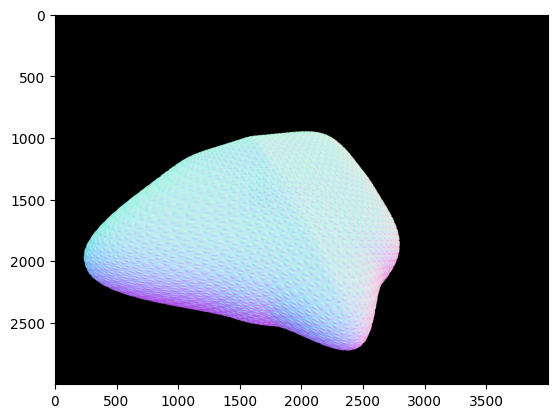

In [56]:
folder_path = "./images/patatoide/"
images = laod_images(folder_path)
plt.imshow(images[-1])
plt.show()

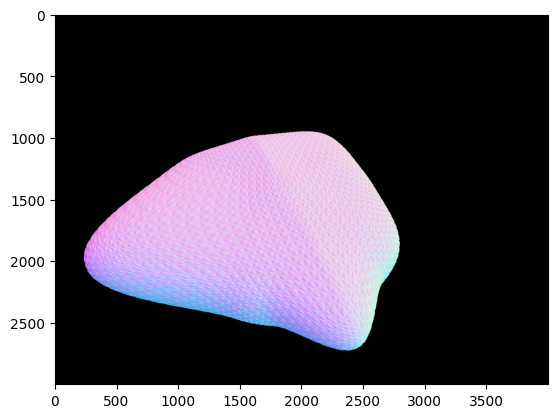

In [58]:
# Matrice de rotation de R360 degrees
R = [[0, 1, 0],
     [1, 0, 0],
     [0, 0, 1]]

changed_images = change_R(images, R)
# Afficher la première image modifiée pour vérification
plt.imshow(changed_images[-1])
plt.show()